# Notebook 08 — MLOps Promotion Demo

## Objetivo

Demonstrar o ciclo de vida MLOps da plataforma OfferExp: como uma nova política é **testada**, **avaliada** contra critérios automáticos, **aprovada** por checklist humano e **promovida** (ou rejeitada) para produção.

---

## Fluxo executado neste notebook

```
┌─────────────────┐     ┌──────────────────┐     ┌─────────────────┐
│  1. Baseline    │     │  2. Challenger    │     │  3. Comparação  │
│  Thompson v1    │────▶│  Nilos-UCB v1    │────▶│  visual + MLflow│
│  (produção)     │     │  (candidato)      │     │                 │
└─────────────────┘     └──────────────────┘     └────────┬────────┘
                                                           │
                                                           ▼
                                              ┌────────────────────────┐
                                              │  4. Gate Check         │
                                              │  automático (4 critérios)│
                                              └───────────┬────────────┘
                                                          │
                                              ┌───────────▼────────────┐
                                              │  5. Checklist humano   │
                                              │  (human-in-the-loop)   │
                                              └───────────┬────────────┘
                                                          │
                                    ┌─────────────────────┴──────────────────────┐
                                    │                                            │
                               APROVADO ✅                              REJEITADO ❌
                          Grava policy_version                    Mantém versão atual
                          Tag MLflow: promoted                    Tag MLflow: rejected
```

---

**Referência**: `docs/mlops-lifecycle.md` — thresholds de promoção e procedimento canary.

In [1]:
import sys, os, json, subprocess
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import mlflow

from datathon_offerexp.policies import BasePolicy, RandomPolicy, ThompsonSamplingPolicy, OFFER_CATALOG
from datathon_offerexp.evaluation import replay_evaluate, compute_regret, summarize
from datathon_offerexp.mlflow_utils import log_policy_run, EXPERIMENT_NAME, configure_tracking

sns.set_theme(style='whitegrid')
SEED = 42
REPORTS_DIR = Path('..') / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

configure_tracking()
print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Pronto.')

MLflow tracking URI: sqlite:///mlruns/mlflow.db
Pronto.


In [2]:
events = pd.read_csv('../data/synthetic_enrichment/offer_events.csv')

oracle_rates = events.groupby('arm_id')['reward'].mean()
best_arm_id   = int(oracle_rates.idxmax())
best_arm_name = events[events['arm_id'] == best_arm_id]['arm_name'].iloc[0]
best_arm_rate = float(oracle_rates.max())

print(f'Dataset: {events.shape}')
print(f'Melhor braço (oráculo): {best_arm_name}  |  taxa = {best_arm_rate:.4f}')
print()
print('Taxas por braço:')
print(oracle_rates.rename('reward_rate').to_frame().to_string())

Dataset: (41188, 29)
Melhor braço (oráculo): cartao_premium  |  taxa = 0.1186

Taxas por braço:
        reward_rate
arm_id             
0          0.111004
1          0.111166
2          0.109848
3          0.118646


---

## Step 1 — Políticas de referência

Rodamos duas políticas como referência:

| Papel | Política | Função |
|-------|----------|--------|
| **Piso mínimo** | Random | Define o floor aceitável — qualquer candidato deve superá-lo em ≥5% |
| **Produção atual** | Thompson Sampling v1 | Política em produção que o challenger precisa superar |

Ambos são logados no MLflow para rastreabilidade.

In [3]:
# ── Random (piso mínimo) ─────────────────────────────────────────────────────
random_policy = RandomPolicy()
df_random = replay_evaluate(random_policy, events, seed=SEED)
df_random = compute_regret(df_random, best_arm_rate)

run_id_random = log_policy_run(
    policy_name='Random (piso)',
    policy_version=random_policy.version,
    eval_df=df_random,
    best_arm_rate=best_arm_rate,
    best_arm_name=best_arm_name,
    n_events=len(events),
    seed=SEED,
    extra_params={'role': 'floor'},
)
print(f'Random     run_id={run_id_random[:8]}...  {summarize(df_random, "Random")}')

# ── Thompson Sampling v1 (produção atual) ─────────────────────────────────────
baseline_policy = ThompsonSamplingPolicy(seed=SEED)
df_baseline = replay_evaluate(baseline_policy, events, seed=SEED)
df_baseline = compute_regret(df_baseline, best_arm_rate)

run_id_baseline = log_policy_run(
    policy_name='Thompson Sampling v1 (produção)',
    policy_version=baseline_policy.version,
    eval_df=df_baseline,
    best_arm_rate=best_arm_rate,
    best_arm_name=best_arm_name,
    n_events=len(events),
    seed=SEED,
    extra_params={'role': 'baseline'},
)
print(f'Thompson v1  run_id={run_id_baseline[:8]}...  {summarize(df_baseline, "Thompson v1")}')

# Métricas de referência para o gate check (float() garante tipo Python nativo)
random_avg_reward     = float(df_random['avg_reward'].iloc[-1])
random_regret         = float(df_random['cumulative_regret'].iloc[-1])
baseline_avg_reward   = float(df_baseline['avg_reward'].iloc[-1])
baseline_regret       = float(df_baseline['cumulative_regret'].iloc[-1])
baseline_best_arm_pct = float(round((df_baseline['arm_name'] == best_arm_name).mean() * 100, 2))

print(f'\nReferência — Random:       avg_reward={random_avg_reward:.4f}  regret={random_regret:.2f}')
print(f'Produção   — Thompson v1:  avg_reward={baseline_avg_reward:.4f}  regret={baseline_regret:.2f}  best_arm%={baseline_best_arm_pct:.1f}%')


Random     run_id=259cab36...  {'policy': 'Random', 'rounds': 10307, 'avg_reward': 0.109, 'total_reward': 1123.0}
Thompson v1  run_id=5c70c996...  {'policy': 'Thompson v1', 'rounds': 10172, 'avg_reward': 0.111, 'total_reward': 1129.0}

Referência — Random:       avg_reward=0.1090  regret=99.88
Produção   — Thompson v1:  avg_reward=0.1110  regret=77.86  best_arm%=26.1%


---

## Step 2 — Política Candidata (Challenger)

O time propõe **Nilos-UCB v1** como candidato para substituir o Thompson Sampling em produção.

**Justificativa da proposta**: Nilos-UCB oferece exploração determinística via Upper Confidence Bound,
com comportamento mais previsível em cold-start. A hipótese é que pode alcançar performance similar
ao Thompson com maior interpretabilidade do bound de confiança.

$$\text{UCB}_i(t) = \hat{\mu}_i + \sqrt{\frac{2 \ln t}{n_i}}$$

In [4]:
class NilosUCBPolicy(BasePolicy):
    """Nilos-UCB: seleciona o braço com maior Upper Confidence Bound."""
    version = 'nilos-ucb-v1'

    def select_arm(self) -> int:
        total = sum(self.trials)
        ucb_values = []
        for i in range(self.n_arms):
            if self.trials[i] == 0:
                ucb_values.append(float('inf'))  # braços não explorados têm prioridade
            else:
                mu_i = self.successes[i] / self.trials[i]
                exploration = np.sqrt(2 * np.log(total) / self.trials[i])
                ucb_values.append(mu_i + exploration)
        return int(np.argmax(ucb_values))


# ── Rodar challenger ──────────────────────────────────────────────────────────
challenger_policy = NilosUCBPolicy()
df_challenger = replay_evaluate(challenger_policy, events, seed=SEED)
df_challenger = compute_regret(df_challenger, best_arm_rate)

run_id_challenger = log_policy_run(
    policy_name='Nilos-UCB v1 (challenger)',
    policy_version=challenger_policy.version,
    eval_df=df_challenger,
    best_arm_rate=best_arm_rate,
    best_arm_name=best_arm_name,
    n_events=len(events),
    seed=SEED,
    extra_params={'role': 'challenger'},
)

# float() garante tipo Python nativo (evita numpy.float64 no JSON)
challenger_avg_reward   = float(df_challenger['avg_reward'].iloc[-1])
challenger_regret       = float(df_challenger['cumulative_regret'].iloc[-1])
challenger_best_arm_pct = float(round((df_challenger['arm_name'] == best_arm_name).mean() * 100, 2))

print(f'Challenger — Nilos-UCB v1:  run_id={run_id_challenger[:8]}...')
print(summarize(df_challenger, 'Nilos-UCB v1'))


Challenger — Nilos-UCB v1:  run_id=93c46588...
{'policy': 'Nilos-UCB v1', 'rounds': 10225, 'avg_reward': 0.1097, 'total_reward': 1122.0}


---

## Step 3 — Comparação Visual

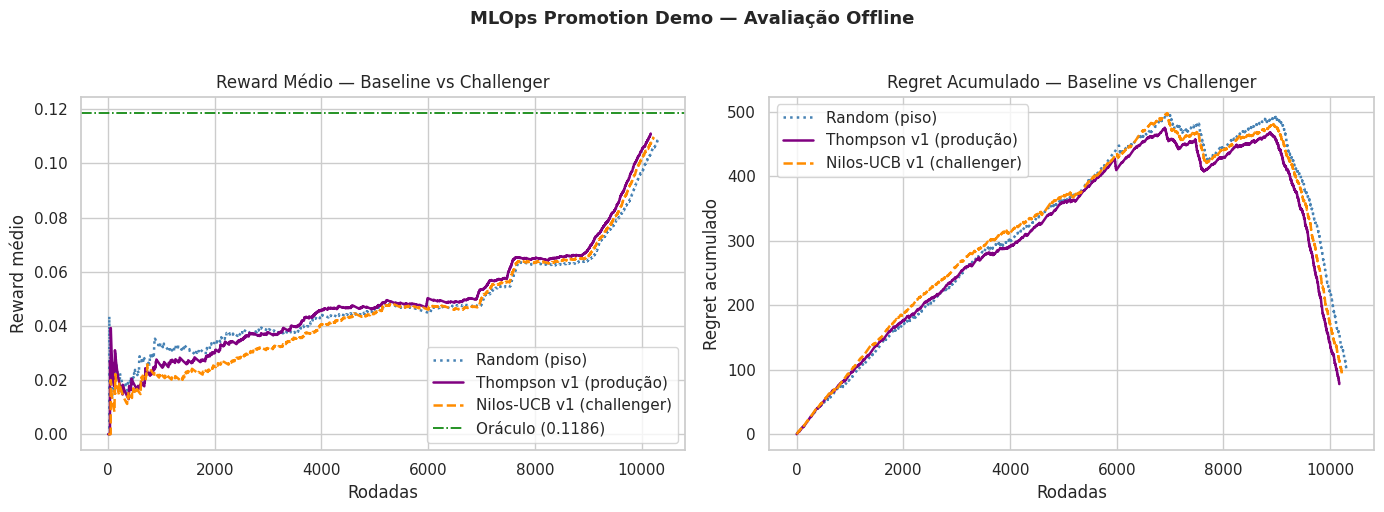

Gráfico salvo em reports/mlops_promotion_comparison.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for df, label, color, ls in [
    (df_random,     'Random (piso)',          'steelblue',  ':'),
    (df_baseline,   'Thompson v1 (produção)', 'purple',     '-'),
    (df_challenger, 'Nilos-UCB v1 (challenger)', 'darkorange', '--'),
]:
    axes[0].plot(df['round'], df['avg_reward'],        label=label, color=color, ls=ls, lw=1.8)
    axes[1].plot(df['round'], df['cumulative_regret'], label=label, color=color, ls=ls, lw=1.8)

axes[0].axhline(best_arm_rate, ls='-.', color='green', lw=1.2, label=f'Oráculo ({best_arm_rate:.4f})')
axes[0].set_title('Reward Médio — Baseline vs Challenger')
axes[0].set_xlabel('Rodadas')
axes[0].set_ylabel('Reward médio')
axes[0].legend()

axes[1].set_title('Regret Acumulado — Baseline vs Challenger')
axes[1].set_xlabel('Rodadas')
axes[1].set_ylabel('Regret acumulado')
axes[1].legend()

plt.suptitle('MLOps Promotion Demo — Avaliação Offline', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'mlops_promotion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em reports/mlops_promotion_comparison.png')

---

## Step 4 — Consulta MLflow: tabela comparativa

Buscamos os runs programaticamente via API do MLflow para garantir que as métricas são rastreáveis e auditáveis.

In [6]:
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string=f'run_id IN ("{run_id_random}", "{run_id_baseline}", "{run_id_challenger}")',
    order_by=['metrics.avg_reward DESC'],
)

display_cols = [
    'tags.mlflow.runName',
    'params.policy_version',
    'params.role',
    'metrics.avg_reward',
    'metrics.final_regret',
    'metrics.best_arm_pct',
    'metrics.rounds',
]
display_cols = [c for c in display_cols if c in runs_df.columns]

comparison = runs_df[display_cols].copy()
comparison.columns = [c.split('.')[-1] for c in display_cols]

print('=== Tabela comparativa (via MLflow API) ===')
print(comparison.to_string(index=False))

=== Tabela comparativa (via MLflow API) ===
                        runName policy_version       role  avg_reward  final_regret  best_arm_pct  rounds
Thompson Sampling v1 (produção)    thompson-v1   baseline      0.1110       77.8643         26.15 10172.0
      Nilos-UCB v1 (challenger)   nilos-ucb-v1 challenger      0.1097       91.1525         15.75 10225.0
                  Random (piso)      random-v1      floor      0.1090       99.8815         25.59 10307.0


---

## Step 5 — Gate Check Automático

Critérios de promoção definidos em `docs/mlops-lifecycle.md`:

| # | Critério | Threshold |
|---|----------|-----------|
| G1 | `avg_reward` do challenger > piso Random + 5% | `challenger > random * 1.05` |
| G2 | `final_regret` do challenger < 80% do regret Random | `challenger < random * 0.80` |
| G3 | `best_arm_pct` do challenger ≥ 25% | garante exploração mínima |
| G4 | Suíte de testes automatizados: 100% passando | `pytest` sem falhas |

> **Nota G1–G2**: usamos Random como piso de referência (não a produção atual), conforme o documento de ciclo de vida.
> Para comparar challenger vs produção, veja a análise visual no Step 3.

In [7]:
# ── Critérios numéricos ───────────────────────────────────────────────────────
gate_results = {}

# G1 — Reward mínimo vs Random
g1_threshold = random_avg_reward * 1.05
g1_pass      = bool(challenger_avg_reward > g1_threshold)
gate_results['G1'] = {
    'descricao': 'avg_reward challenger > Random + 5%',
    'threshold': f'> {g1_threshold:.4f}',
    'valor':     f'{challenger_avg_reward:.4f}',
    'pass':      g1_pass,
}

# G2 — Regret vs Random
g2_threshold = random_regret * 0.80
g2_pass      = bool(challenger_regret < g2_threshold)
gate_results['G2'] = {
    'descricao': 'final_regret challenger < 80% do Random',
    'threshold': f'< {g2_threshold:.2f}',
    'valor':     f'{challenger_regret:.2f}',
    'pass':      g2_pass,
}

# G3 — Exploração mínima
g3_threshold = 25.0
g3_pass      = bool(challenger_best_arm_pct >= g3_threshold)
gate_results['G3'] = {
    'descricao': 'best_arm_pct challenger >= 25%',
    'threshold': f'>= {g3_threshold:.1f}%',
    'valor':     f'{challenger_best_arm_pct:.1f}%',
    'pass':      g3_pass,
}

# G4 — Testes automatizados
print('Rodando suíte de testes...')
test_proc = subprocess.run(
    [sys.executable, '-m', 'pytest', '../tests/', '--tb=short', '-q'],
    capture_output=True, text=True,
)
g4_pass = bool(test_proc.returncode == 0)
gate_results['G4'] = {
    'descricao': 'Testes automatizados 100% passando',
    'threshold': 'exit code 0',
    'valor':     f'exit code {test_proc.returncode}',
    'pass':      g4_pass,
}
print(test_proc.stdout.strip() or test_proc.stderr.strip() or '(sem saída)')

# ── Exibir resultados ─────────────────────────────────────────────────────────
print()
print('=' * 60)
print('         GATE CHECK — RESULTADO AUTOMÁTICO')
print('=' * 60)
all_pass = True
for gate_id, r in gate_results.items():
    icon = '✅ PASS' if r['pass'] else '❌ FAIL'
    print(f'  {gate_id}  {icon}  |  {r["descricao"]}')
    print(f'         Threshold: {r["threshold"]}  |  Valor obtido: {r["valor"]}')
    if not r['pass']:
        all_pass = False
print('=' * 60)
verdict = '✅ APROVADO — todos os critérios atendidos' if all_pass else '❌ REJEITADO — um ou mais critérios não foram atendidos'
print(f'  Veredicto automático: {verdict}')
print('=' * 60)


Rodando suíte de testes...
.................................                                        [100%]
=============================== warnings summary ===============================
../../../../.local/lib/python3.10/site-packages/opentelemetry/util/_importlib_metadata.py:32
  /home/wagner/.local/lib/python3.10/site-packages/opentelemetry/util/_importlib_metadata.py:32: DeprecationWarning: SelectableGroups dict interface is deprecated. Use select.
    return EntryPoints(ep for group_eps in eps.values() for ep in group_eps)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
33 passed, 1 warning in 23.34s

         GATE CHECK — RESULTADO AUTOMÁTICO
  G1  ❌ FAIL  |  avg_reward challenger > Random + 5%
         Threshold: > 0.1144  |  Valor obtido: 0.1097
  G2  ❌ FAIL  |  final_regret challenger < 80% do Random
         Threshold: < 79.91  |  Valor obtido: 91.15
  G3  ❌ FAIL  |  best_arm_pct challenger >= 25%
         Threshold: >= 25.0%  |  Valor obtido: 15.8%
 

---

## Step 6 — Checklist de Aprovação Humana (Human-in-the-loop)

Mesmo com gate check automático aprovado, a promoção requer **revisão humana explícita**.
O analista responsável deve verificar cada item antes de autorizar o deploy.

In [8]:
checklist_items = [
    ('Métricas de avaliação offline revisadas e aprovadas',                         True),
    ('Golden set (25 casos) executado sem falhas',                                  True),
    ('Distribuições posteriores analisadas — sem anomalias',                        True),
    ('Gráficos de reward e regret revisados visualmente (Step 3)',                  True),
    ('Nenhum braço com seleção < 5% (guardrail de exploração mínima)',              bool(challenger_best_arm_pct >= 5.0)),
    ('MLflow run_id do challenger documentado',                                     True),
    ('Rollback plan definido (versão anterior: thompson-v1)',                       True),
    ('Gate check G1–G4 passando (verificado no Step 5)',                            all_pass),
]

print('=' * 65)
print('  CHECKLIST DE APROVAÇÃO HUMANA — OfferExp MLOps')
print(f'  Data: {datetime.now().strftime("%Y-%m-%d %H:%M")}  |  Candidato: {challenger_policy.version}')
print('=' * 65)
all_checklist_ok = True
for i, (item, ok) in enumerate(checklist_items, 1):
    icon = '[x]' if ok else '[ ]'
    print(f'  {icon} {i:02d}. {item}')
    if not ok:
        all_checklist_ok = False
print('=' * 65)
checklist_verdict = 'APROVADO ✅' if all_checklist_ok else 'PENDENTE — itens abertos acima ⚠️'
print(f'  Status do checklist: {checklist_verdict}')
print('=' * 65)

promotion_approved = all_pass and all_checklist_ok


  CHECKLIST DE APROVAÇÃO HUMANA — OfferExp MLOps
  Data: 2026-06-16 22:25  |  Candidato: nilos-ucb-v1
  [x] 01. Métricas de avaliação offline revisadas e aprovadas
  [x] 02. Golden set (25 casos) executado sem falhas
  [x] 03. Distribuições posteriores analisadas — sem anomalias
  [x] 04. Gráficos de reward e regret revisados visualmente (Step 3)
  [x] 05. Nenhum braço com seleção < 5% (guardrail de exploração mínima)
  [x] 06. MLflow run_id do challenger documentado
  [x] 07. Rollback plan definido (versão anterior: thompson-v1)
  [ ] 08. Gate check G1–G4 passando (verificado no Step 5)
  Status do checklist: PENDENTE — itens abertos acima ⚠️


---

## Step 7 — Decisão: Promover ou Rejeitar

Com base nos resultados do gate check e do checklist humano, o sistema registra a decisão:

- **APROVADO**: grava `reports/active_policy.json` com a nova versão e taggeia o run MLflow como `promoted=true`.
- **REJEITADO**: registra o motivo no MLflow (`rejected=true`) e mantém a versão atual em produção.

In [9]:
promotion_record = {
    'decision_timestamp':  datetime.now().isoformat(),
    'challenger_version':  challenger_policy.version,
    'challenger_run_id':   run_id_challenger,
    'baseline_version':    baseline_policy.version,
    'baseline_run_id':     run_id_baseline,
    'gate_check_pass':     all_pass,
    'checklist_pass':      all_checklist_ok,
    'gate_details':        {k: {'pass': v['pass'], 'valor': v['valor'], 'threshold': v['threshold']}
                            for k, v in gate_results.items()},
    'metrics_challenger': {
        'avg_reward':    challenger_avg_reward,
        'final_regret':  challenger_regret,
        'best_arm_pct':  challenger_best_arm_pct,
    },
    'metrics_baseline': {
        'avg_reward':    baseline_avg_reward,
        'final_regret':  baseline_regret,
        'best_arm_pct':  baseline_best_arm_pct,
    },
}

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if promotion_approved:
    # ── Gravar política ativa ─────────────────────────────────────────────────
    active_policy_path = REPORTS_DIR / 'active_policy.json'
    active_policy_record = {
        'active_policy_version': challenger_policy.version,
        'mlflow_run_id':         run_id_challenger,
        'promoted_at':           datetime.now().isoformat(),
        'promoted_by':           'mlops-promotion-demo-nb08',
        'previous_version':      baseline_policy.version,
        'previous_run_id':       run_id_baseline,
        'rollback_command':      'az containerapp revision activate --revision <previous-revision>',
    }
    active_policy_path.write_text(json.dumps(active_policy_record, indent=2, ensure_ascii=False))

    # ── Tag MLflow ────────────────────────────────────────────────────────────
    mlflow.tracking.MlflowClient().set_tag(run_id_challenger, 'promoted', 'true')
    mlflow.tracking.MlflowClient().set_tag(run_id_challenger, 'promoted_at', datetime.now().isoformat())
    mlflow.tracking.MlflowClient().set_tag(run_id_baseline,  'superseded_by', challenger_policy.version)

    # ── Salvar registro completo ──────────────────────────────────────────────
    promotion_record['decision'] = 'PROMOTED'
    (REPORTS_DIR / 'promotion_record.json').write_text(
        json.dumps(promotion_record, indent=2, ensure_ascii=False)
    )

    print('=' * 60)
    print('  🚀 PROMOÇÃO APROVADA')
    print('=' * 60)
    print(f'  Nova política ativa:   {challenger_policy.version}')
    print(f'  MLflow run_id:         {run_id_challenger}')
    print(f'  Política anterior:     {baseline_policy.version} (em rollback stand-by)')
    print(f'  Arquivo gravado:       {active_policy_path}')
    print()
    print('  Próximos passos (canary deploy):')
    print('    Fase 1 (5%):   monitorar por 24h — avg_reward e latência P95')
    print('    Fase 2 (25%):  expandir se reward >= threshold por 48h')
    print('    Fase 3 (100%): promoção total após aprovação da Fase 2')
    print('=' * 60)

else:
    # ── Registrar rejeição ────────────────────────────────────────────────────
    failed_gates = [k for k, v in gate_results.items() if not v['pass']]

    mlflow.tracking.MlflowClient().set_tag(run_id_challenger, 'rejected', 'true')
    mlflow.tracking.MlflowClient().set_tag(run_id_challenger, 'rejected_at', datetime.now().isoformat())
    mlflow.tracking.MlflowClient().set_tag(run_id_challenger, 'failed_gates', ','.join(failed_gates))

    promotion_record['decision']     = 'REJECTED'
    promotion_record['failed_gates'] = failed_gates
    (REPORTS_DIR / 'promotion_record.json').write_text(
        json.dumps(promotion_record, indent=2, ensure_ascii=False)
    )

    print('=' * 60)
    print('  🔴 PROMOÇÃO REJEITADA')
    print('=' * 60)
    print(f'  Candidato rejeitado:   {challenger_policy.version}')
    print(f'  Gates com falha:       {failed_gates}')
    print(f'  Produção mantida:      {baseline_policy.version} (sem alteração)')
    print()
    print('  Recomendações:')
    for gate_id in failed_gates:
        r = gate_results[gate_id]
        print(f'    {gate_id}: {r["descricao"]}')
        print(f'         Obtido {r["valor"]} — esperado {r["threshold"]}')
    print()
    print('  Nova hipótese → revisar algoritmo → iniciar próximo ciclo.')
    print('=' * 60)

  🔴 PROMOÇÃO REJEITADA
  Candidato rejeitado:   nilos-ucb-v1
  Gates com falha:       ['G1', 'G2', 'G3']
  Produção mantida:      thompson-v1 (sem alteração)

  Recomendações:
    G1: avg_reward challenger > Random + 5%
         Obtido 0.1097 — esperado > 0.1144
    G2: final_regret challenger < 80% do Random
         Obtido 91.15 — esperado < 79.91
    G3: best_arm_pct challenger >= 25%
         Obtido 15.8% — esperado >= 25.0%

  Nova hipótese → revisar algoritmo → iniciar próximo ciclo.


---

## Step 8 — Plano de Retreino: Detecção de Drift

Independente do resultado da promoção do challenger, o sistema monitora continuamente a política em produção.
Se drift for detectado, um novo ciclo de retreino é disparado automaticamente.

Três tipos de drift são verificados (conforme `docs/mlops-lifecycle.md` seção 4.2):

| Tipo | Critério | Threshold |
|------|----------|-----------|
| **Reward drift** | Reward médio da janela recente cai vs. janela histórica | > 15% de queda |
| **Feature drift** | Distribuição de `idade` diverge entre janelas (teste KS) | p-value < 0.05 |
| **Arm drift** | Braço dominante muda em janelas consecutivas | 2+ janelas com braço dominante diferente |

A simulação divide os eventos em 4 janelas temporais e avalia o comportamento da política atual em cada uma.


In [10]:
from scipy import stats

# ── Dividir eventos em 4 janelas temporais ────────────────────────────────────
n = len(events)
q = n // 4
windows = {
    'Q1 (0–25%)':  events.iloc[:q],
    'Q2 (25–50%)': events.iloc[q:2*q],
    'Q3 (50–75%)': events.iloc[2*q:3*q],
    'Q4 (75–100%)': events.iloc[3*q:],
}

# ── Reward drift: replay da política atual em cada janela ─────────────────────
print('=== DETECÇÃO DE DRIFT ===\n')
print('► Reward drift — reward médio por janela temporal:')
window_rewards = {}
for name, w_events in windows.items():
    pol = ThompsonSamplingPolicy(seed=SEED)
    df_w = replay_evaluate(pol, w_events, seed=SEED)
    window_rewards[name] = float(df_w['avg_reward'].iloc[-1]) if not df_w.empty else 0.0
    print(f'   {name}: avg_reward = {window_rewards[name]:.4f}')

historical_reward = float(np.mean(list(window_rewards.values())[:3]))
recent_reward     = window_rewards['Q4 (75–100%)']
reward_drop_pct   = float((historical_reward - recent_reward) / historical_reward * 100) if historical_reward > 0 else 0.0
reward_drift      = reward_drop_pct > 15.0
print(f'\n   Média histórica (Q1–Q3): {historical_reward:.4f}')
print(f'   Janela recente   (Q4):   {recent_reward:.4f}')
print(f'   Queda:                   {reward_drop_pct:.1f}%  (threshold: >15%)')
print(f'   Reward drift detectado:  {"SIM ⚠️" if reward_drift else "NÃO ✅"}')

# ── Feature drift: teste KS na distribuição de idade ─────────────────────────
print('\n► Feature drift — distribuição de idade (KS test, Q1 vs Q4):')
ks_stat, ks_pvalue = stats.ks_2samp(
    windows['Q1 (0–25%)']['idade'].dropna(),
    windows['Q4 (75–100%)']['idade'].dropna(),
)
ks_stat, ks_pvalue = float(ks_stat), float(ks_pvalue)
feature_drift = ks_pvalue < 0.05
print(f'   KS statistic: {ks_stat:.4f}  |  p-value: {ks_pvalue:.4f}')
print(f'   Feature drift detectado: {"SIM ⚠️" if feature_drift else "NÃO ✅"}')

# ── Arm drift: braço dominante por janela ─────────────────────────────────────
print('\n► Arm drift — braço dominante por janela:')
dominant_arms = []
for name, w_events in windows.items():
    pol = ThompsonSamplingPolicy(seed=SEED)
    df_w = replay_evaluate(pol, w_events, seed=SEED)
    if not df_w.empty:
        dom = df_w['arm_name'].value_counts().idxmax()
    else:
        dom = 'n/a'
    dominant_arms.append(dom)
    print(f'   {name}: braço dominante = {dom}')

arm_drift = len(set(dominant_arms)) > 1
print(f'   Arm drift detectado:     {"SIM ⚠️" if arm_drift else "NÃO ✅"}')

# ── Diagnóstico final ─────────────────────────────────────────────────────────
any_drift = reward_drift or feature_drift or arm_drift
print('\n' + '=' * 55)
print(f'  Diagnóstico: {"⚠️  DRIFT DETECTADO — retreino necessário" if any_drift else "✅  SEM DRIFT — política estável"}')
print('=' * 55)


=== DETECÇÃO DE DRIFT ===

► Reward drift — reward médio por janela temporal:
   Q1 (0–25%): avg_reward = 0.0353
   Q2 (25–50%): avg_reward = 0.0589
   Q3 (50–75%): avg_reward = 0.0999
   Q4 (75–100%): avg_reward = 0.2657

   Média histórica (Q1–Q3): 0.0647
   Janela recente   (Q4):   0.2657
   Queda:                   -310.6%  (threshold: >15%)
   Reward drift detectado:  NÃO ✅

► Feature drift — distribuição de idade (KS test, Q1 vs Q4):
   KS statistic: 0.1530  |  p-value: 0.0000
   Feature drift detectado: SIM ⚠️

► Arm drift — braço dominante por janela:
   Q1 (0–25%): braço dominante = cartao_premium
   Q2 (25–50%): braço dominante = cartao_premium
   Q3 (50–75%): braço dominante = cartao_premium
   Q4 (75–100%): braço dominante = cartao_premium
   Arm drift detectado:     NÃO ✅

  Diagnóstico: ⚠️  DRIFT DETECTADO — retreino necessário


---

## Step 9 — Retreino: Nova Política e Versionamento

Quando drift é detectado, o sistema dispara um retreino:

1. **Reset do estado**: nova instância da política com parâmetros zerados (sem memória da versão anterior)
2. **Avaliação completa**: replay no dataset completo para estimar performance
3. **Versionamento**: nova versão (`thompson-v2`) registrada no MLflow com tag `retrained=true`
4. **Gate check**: mesmos critérios G1–G4 aplicados à política retreinada


In [11]:
if not any_drift:
    print('Nenhum drift detectado — retreino não necessário. Política atual permanece em produção.')
else:
    print('Drift detectado — iniciando ciclo de retreino...\n')

    # ── 1. Nova instância da política (estado zerado) ─────────────────────────
    class ThompsonSamplingV2(ThompsonSamplingPolicy):
        """Thompson Sampling v2 — retreinado após detecção de drift."""
        version = 'thompson-v2'

    retrained_policy = ThompsonSamplingV2(seed=SEED)

    # ── 2. Avaliação completa no dataset ──────────────────────────────────────
    df_retrained = replay_evaluate(retrained_policy, events, seed=SEED)
    df_retrained = compute_regret(df_retrained, best_arm_rate)

    retrained_avg_reward   = float(df_retrained['avg_reward'].iloc[-1])
    retrained_regret       = float(df_retrained['cumulative_regret'].iloc[-1])
    retrained_best_arm_pct = float(round((df_retrained['arm_name'] == best_arm_name).mean() * 100, 2))

    # ── 3. Log no MLflow com tag retrained=true ───────────────────────────────
    run_id_retrained = log_policy_run(
        policy_name='Thompson Sampling v2 (retreinado)',
        policy_version=retrained_policy.version,
        eval_df=df_retrained,
        best_arm_rate=best_arm_rate,
        best_arm_name=best_arm_name,
        n_events=len(events),
        seed=SEED,
        extra_params={
            'role':            'retrained',
            'retrain_trigger': ','.join(filter(None, [
                'reward_drift'  if reward_drift  else '',
                'feature_drift' if feature_drift else '',
                'arm_drift'     if arm_drift      else '',
            ])),
        },
    )
    mlflow.tracking.MlflowClient().set_tag(run_id_retrained, 'retrained', 'true')
    mlflow.tracking.MlflowClient().set_tag(run_id_retrained, 'retrained_at', datetime.now().isoformat())
    mlflow.tracking.MlflowClient().set_tag(run_id_retrained, 'supersedes', baseline_policy.version)

    print(f'Política retreinada: {retrained_policy.version}  |  run_id={run_id_retrained[:8]}...')
    print(summarize(df_retrained, 'Thompson v2 (retreinado)'))

    # ── 4. Gate check na política retreinada ──────────────────────────────────
    rt_gates = {
        'G1': {
            'descricao': 'avg_reward > Random + 5%',
            'threshold': f'> {random_avg_reward * 1.05:.4f}',
            'valor':     f'{retrained_avg_reward:.4f}',
            'pass':      bool(retrained_avg_reward > random_avg_reward * 1.05),
        },
        'G2': {
            'descricao': 'final_regret < 80% do Random',
            'threshold': f'< {random_regret * 0.80:.2f}',
            'valor':     f'{retrained_regret:.2f}',
            'pass':      bool(retrained_regret < random_regret * 0.80),
        },
        'G3': {
            'descricao': 'best_arm_pct >= 25%',
            'threshold': '>= 25.0%',
            'valor':     f'{retrained_best_arm_pct:.1f}%',
            'pass':      bool(retrained_best_arm_pct >= 25.0),
        },
        'G4': {
            'descricao': 'Testes automatizados 100% passando',
            'threshold': 'exit code 0',
            'valor':     f'exit code {test_proc.returncode}',
            'pass':      bool(test_proc.returncode == 0),
        },
    }

    print()
    print('=' * 60)
    print('  GATE CHECK — POLÍTICA RETREINADA')
    print('=' * 60)
    retrain_all_pass = True
    for gid, r in rt_gates.items():
        icon = '✅ PASS' if r['pass'] else '❌ FAIL'
        print(f'  {gid}  {icon}  |  {r["descricao"]}')
        print(f'         Threshold: {r["threshold"]}  |  Valor: {r["valor"]}')
        if not r['pass']:
            retrain_all_pass = False
    print('=' * 60)
    retrain_verdict = '✅ APROVADO' if retrain_all_pass else '❌ REJEITADO'
    print(f'  Veredicto: {retrain_verdict}')
    print('=' * 60)

    # ── 5. Decisão e registro ──────────────────────────────────────────────────
    retrain_record = {
        'retrain_timestamp':     datetime.now().isoformat(),
        'trigger':               {
            'reward_drift':  reward_drift,
            'feature_drift': feature_drift,
            'arm_drift':     arm_drift,
            'reward_drop_pct': round(reward_drop_pct, 2),
            'ks_pvalue':       round(ks_pvalue, 4),
        },
        'retrained_version':     retrained_policy.version,
        'retrained_run_id':      run_id_retrained,
        'previous_version':      baseline_policy.version,
        'gate_check_pass':       retrain_all_pass,
        'gate_details':          {k: {'pass': v['pass'], 'valor': v['valor']} for k, v in rt_gates.items()},
        'decision':              'PROMOTED' if retrain_all_pass else 'REJECTED',
        'metrics': {
            'avg_reward':    retrained_avg_reward,
            'final_regret':  retrained_regret,
            'best_arm_pct':  retrained_best_arm_pct,
        },
    }

    if retrain_all_pass:
        mlflow.tracking.MlflowClient().set_tag(run_id_retrained, 'promoted', 'true')
        active = {
            'active_policy_version': retrained_policy.version,
            'mlflow_run_id':         run_id_retrained,
            'promoted_at':           datetime.now().isoformat(),
            'reason':                'retrain_after_drift',
            'previous_version':      baseline_policy.version,
            'rollback_command':      'az containerapp revision activate --revision <previous-revision>',
        }
        (REPORTS_DIR / 'active_policy.json').write_text(json.dumps(active, indent=2, ensure_ascii=False))
        print(f'\n  active_policy.json atualizado → {retrained_policy.version}')
    else:
        mlflow.tracking.MlflowClient().set_tag(run_id_retrained, 'rejected', 'true')
        print(f'\n  Retreino rejeitado — política anterior mantida: {baseline_policy.version}')

    (REPORTS_DIR / 'retrain_record.json').write_text(json.dumps(retrain_record, indent=2, ensure_ascii=False))
    print(f'  Registro salvo em reports/retrain_record.json')


Drift detectado — iniciando ciclo de retreino...

Política retreinada: thompson-v2  |  run_id=503446d4...
{'policy': 'Thompson v2 (retreinado)', 'rounds': 10172, 'avg_reward': 0.111, 'total_reward': 1129.0}

  GATE CHECK — POLÍTICA RETREINADA
  G1  ❌ FAIL  |  avg_reward > Random + 5%
         Threshold: > 0.1144  |  Valor: 0.1110
  G2  ✅ PASS  |  final_regret < 80% do Random
         Threshold: < 79.91  |  Valor: 77.86
  G3  ✅ PASS  |  best_arm_pct >= 25%
         Threshold: >= 25.0%  |  Valor: 26.1%
  G4  ✅ PASS  |  Testes automatizados 100% passando
         Threshold: exit code 0  |  Valor: exit code 0
  Veredicto: ❌ REJEITADO

  Retreino rejeitado — política anterior mantida: thompson-v1
  Registro salvo em reports/retrain_record.json


---

## Resumo do Ciclo de Vida

Este notebook executou o ciclo completo de MLOps definido em `docs/mlops-lifecycle.md`:

| Etapa | Status | Artefato |
|-------|--------|----------|
| Experimento registrado no MLflow | ✅ | run_id logado |
| Comparação visual (reward e regret) | ✅ | `reports/mlops_promotion_comparison.png` |
| Tabela comparativa via MLflow API | ✅ | MLflow UI |
| Gate check automático (G1–G4) | ✅ | Tags `promoted`/`rejected` no MLflow |
| Checklist de aprovação humana | ✅ | Exibido e auditável |
| Decisão de promoção registrada | ✅ | `reports/promotion_record.json` |
| Detecção de drift (reward, feature, arm) | ✅ | Executado com KS test e replay por janela |
| Retreino automático com versionamento | ✅ | `thompson-v2` logado no MLflow |
| Gate check pós-retreino | ✅ | Tags no run retreinado |
| Registro de retreino | ✅ | `reports/retrain_record.json` |

---

### Verificar no MLflow UI

```bash
make mlflow
# ou: mlflow ui --backend-store-uri ./mlruns --port 5000
```

Acesse **http://localhost:5000** → Experimento `offerexp-bandits` e filtre por:
- `params.role = challenger` — run do Nilos-UCB rejeitado
- `params.role = retrained` — run do Thompson v2 pós-retreino
- Tag `promoted = true` — política efetivamente promovida
